In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from IPython.display import Image, display
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("imdb_top_1000.csv")

In [3]:
# DATA CLEANING
df = df.rename(columns={"Series_Title": "Title"})
df = df.rename(columns={"Runtime": "Runtime(mins)"})
# clean meta score
df["Meta_score"] = (
    df["Meta_score"]
    .astype(str)
    .str.replace("nan", "")
)

# convert invalid to NaN
df["Meta_score"] = pd.to_numeric(df["Meta_score"], errors="coerce")

# fill NaN with mean
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].mean())

# clean gross column
df["Gross"] = (
    df["Gross"]
    .fillna("0")
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(".0", "", regex=False)
    .str.replace(".00", "", regex=False)
)

# convert gross to int
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce").fillna(0).astype(int)

# clean runtime column
df["Runtime(mins)"] = (
    df["Runtime(mins)"]
    .astype(str)
    .str.replace(" min", "", regex=False)
)

# convert runtime to int
df["Runtime(mins)"] = pd.to_numeric(df["Runtime(mins)"], errors="coerce").fillna(0).astype(int)

# clean votes column
df["No_of_Votes"] = pd.to_numeric(df["No_of_Votes"], errors="coerce").fillna(0).astype(int)

# set title index
df = df.set_index("Title")


In [4]:
# FUNCTION 1. ANALYSER FUNCTION
def movie_info():
   
    movie = input("Enter movie name: ").strip()
    
    if movie in df.index:
        print("\n========================")
        print("MOVIE INFORMATION")
        print("========================\n")
        poster_url = df.loc[movie, "Poster_Link"]
        print("\nPoster:\n")
        display(Image(url=poster_url))
        print(df.loc[movie])
    else:
        print("Movie not found!")
#----------------------------------------------------------------------------------------------------------------------

def top_rated():
   
    print("\n======== TOP RATED MOVIES ========\n")
    n = int(input("How many movies do you want to see? "))
    topN = df.sort_values("IMDB_Rating", ascending=False).head(n)
    print(topN["IMDB_Rating"].to_string())


def highest_grossing():
  
    print("\n======== HIGHEST GROSSING MOVIES ========\n")
    n = int(input("How many movies do you want to see? "))
    topN = df.sort_values("Gross", ascending=False).head(n)
    print(topN["Gross"].to_string())


def most_runtime():
   
    print("\n======== LONGEST RUNTIME MOVIES ========\n")
    n = int(input("How many movies do you want to see? "))
    topN = df.sort_values("Runtime(mins)", ascending=False).head(n)
    print(topN["Runtime(mins)"].to_string())


def most_votes():
   
    print("\n======== MOST VOTED MOVIES ========\n")
    n = int(input("How many movies do you want to see? "))
    topN = df.sort_values("No_of_Votes", ascending=False).head(n)
    print(topN["No_of_Votes"].to_string())


def Stats():
    print("\nWELCOME TO MOVIE STATISTICS\n")
    print("Select the Statistics you want to Display")
    print("1. Top rated Movies")
    print("2. Highest Grossing Movies")
    print("3. Longest Runtime")
    print("4. Most Votes\n")

    choice = input("Enter your choice: ")

    if choice == "1":
        top_rated()
    elif choice == "2":
        highest_grossing()
    elif choice == "3":
        most_runtime()
    elif choice == "4":
        most_votes()
    else:
        print("Invalid choice!")


#----------------------------------------------------------------------------------------------------------------------
def get_overview():
    movie = input("Enter movie name: ").strip()

    if movie not in df.index:
        print("Movie not found")
        return
    
    print("\nTITLE:")
    print(movie)

    print("\nCAST:")
    print(df.loc[movie, ["Star1", "Star2", "Star3", "Star4"]])

    print("\nOVERVIEW:")
    print(df.loc[movie, "Overview"])
#----------------------------------------------------------------------------------------------------------------------
def Analyser():
    print("\n========================")
    print("WELCOME TO DATA ANALYSER")
    print("========================\n")
    print("Select the function you want to use ")
    print("1.Movie Search\n2.Stats\n3.Get Overview")
    z=input()
    if z=="1":
        movie_info()
    elif z=="2":
        Stats()
    elif z=="3":
        get_overview()
    else:
        print("invalid input")


In [5]:
# FUNCTION 2. RECOMENDATION SYSTEM
def recom():
    print("Which type of movie would you like to watch?")

    # ask questions
    genre = input("Enter genre (or leave blank): ").strip().lower()
    actor = input("Enter lead actor (Star1) (or leave blank): ").strip().lower()
    director = input("Enter director (or leave blank): ").strip().lower()

    # Start with full dataset
    results = df.copy()

    # 1. Filter by genre (case-insensitive substring match)
    if genre != "":
        results = results[results["Genre"].str.lower().str.contains(genre)]

    # 2. Filter by lead actor
    if actor != "":
        results = results[results["Star1"].str.lower().str.contains(actor)]

    # 3. Filter by director
    if director != "":
        results = results[results["Director"].str.lower().str.contains(director)]

    # Check if empty
    if results.empty:
        print("\nNo movies match your description.")
        return

    # Show a simple list of results
    print("\nHERE IS A LIST OF MOVIES THAT FIT YOUR DESCRIPTION:\n")
    for title in results.index:
        print("\n",title)
    

In [6]:
# FUNCTION 3. GRAPHS
def graph_comp_menu():
    def plot_top_actors():
        n = int(input("How many top lead actors (Star1) to show? "))
    
        # take only Star1 column
        actors = df["Star1"].dropna()       # remove NaN
        actors = actors[actors != ""]       # remove empty strings
    
        # count actors and take top n
        counts = actors.value_counts().head(n)
    
        # plot
        plt.figure(figsize=(10,5))
        plt.barh(counts.index, counts.values)
        plt.title(f"Top {n} Lead Actors (Star1)")
        plt.xlabel("Number of Movies")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    def plot_top_directors():
        n = int(input("How many top directors to show? "))
    
        directors = df["Director"].dropna()     # remove NaN
        directors = directors[directors != ""]  # remove empty strings
    
        counts = directors.value_counts().head(n)
    
        plt.figure(figsize=(10,5))
        plt.barh(counts.index, counts.values)
        plt.title(f"Top {n} Directors")
        plt.xlabel("Number of Movies")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    def relation():
        plt.figure(figsize=(12,5))
        plt.scatter(range(len(df)), df["Runtime(mins)"], s=10, color="blue")
        plt.xlabel("Movie Index (0 to 999)")
        plt.ylabel("Runtime (minutes)")
        plt.title("Relation Between Movies and Their Runtime")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10,5))
        plt.scatter(df["Runtime(mins)"], df["IMDB_Rating"], s=15, color="purple")

        plt.xlabel("Runtime (minutes)")
        plt.ylabel("IMDB Rating")
        plt.title("IMDB Rating vs Runtime")
        plt.grid(True)

        plt.show()


        
    
    print("enter 1: graph of Top Lead actors")
    print("enter 2: graph of Top Directors")
    print("enter 3: rating vs runtime relation")
    

    sub = input("Enter choice: ")
    if sub == "1":
        plot_top_actors()
    elif sub == "2":
        plot_top_directors()
    elif sub == "3":
        relation()
    elif sub == "4":
        print("Returning to main menu...")
    else:
        print("Invalid choice.")

In [7]:
# FUNCTION 4. POSTERS 
def poster():
    title = input("Enter movie title (exact Title): ").strip()
    
    # --- RANDOM POSTER MODE ---
    if title.lower() == "random":
        row = df.sample(1).iloc[0]
        poster_url = row["Poster_Link"]
        print("\nRandom movie:", row.name)   # row.name = index (Title)

        if pd.isna(poster_url) or poster_url.strip() == "":
            display(Image(filename=FALLBACK_POSTER, width=100))
        else:
            display(Image(url=poster_url, width=100))
        return

    # Case-insensitive exact match (index-based)
    lower_index = df.index.str.lower()

    if title.lower() not in lower_index:
        print("Invalid input")
        return

    # find the real index position
    idx = lower_index.tolist().index(title.lower())
    row = df.iloc[idx]

    poster_url = row["Poster_Link"]

    print("\n##################\n")
    
    if pd.isna(poster_url) or poster_url.strip() == "":
        print("Poster missing — showing fallback image.")
        display(Image(filename=FALLBACK_POSTER, width=100))
    else:
        display(Image(url=poster_url, width=100))
 




██ ██▄  ▄██ ████▄  ▄▄▄▄      ▄████▄ ███  ██ ▄████▄ ██    ██  ██ ▄█████ ██ ▄█████   ██████ ▄████▄ ▄████▄ ██     
██ ██ ▀▀ ██ ██  ██ ██▄██ ▄▄▄ ██▄▄██ ██ ▀▄██ ██▄▄██ ██     ▀██▀  ▀▀▀▄▄▄ ██ ▀▀▀▄▄▄     ██   ██  ██ ██  ██ ██     
██ ██    ██ ████▀  ██▄█▀     ██  ██ ██   ██ ██  ██ ██████  ██   █████▀ ██ █████▀     ██   ▀████▀ ▀████▀ ██████ █

      welcome to the I M D B   D A T A S E T   T O O L...




------------------------------------------------------------------------------

Enter 1 for Analysis

Enter 2 for Movie Recommendations

Enter 3 for Graphical Comparisons

Enter 4 to See Posters



Enter your choice:  1


You selected: 1

WELCOME TO DATA ANALYSER

Select the function you want to use 
1.Movie Search
2.Stats
3.Get Overview


 1
Enter movie name:  Inception



MOVIE INFORMATION


Poster:



...

press 1 to go back to main menu OR press x to exit 1




------------------------------------------------------------------------------

Enter 1 for Analysis

Enter 2 for Movie Recommendations

Enter 3 for Graphical Comparisons

Enter 4 to See Posters



Enter your choice:  3


You selected: 3
enter 1: graph of Top Lead actors
enter 2: graph of Top Directors
enter 3: rating vs runtime relation


Enter choice:  1
How many top lead actors (Star1) to show?  20


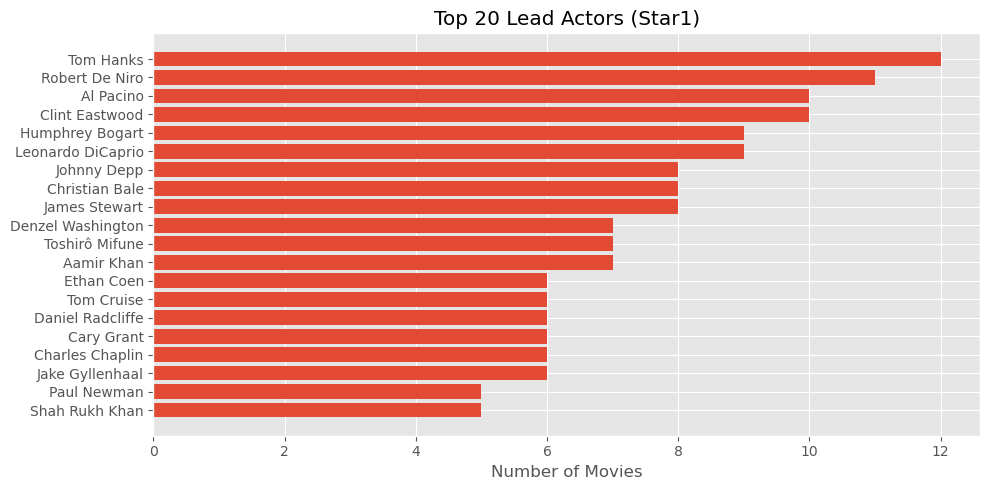

press 1 to go back to main menu OR press x to exit 1




------------------------------------------------------------------------------

Enter 1 for Analysis

Enter 2 for Movie Recommendations

Enter 3 for Graphical Comparisons

Enter 4 to See Posters



Enter your choice:  3


You selected: 3
enter 1: graph of Top Lead actors
enter 2: graph of Top Directors
enter 3: rating vs runtime relation


Enter choice:  3


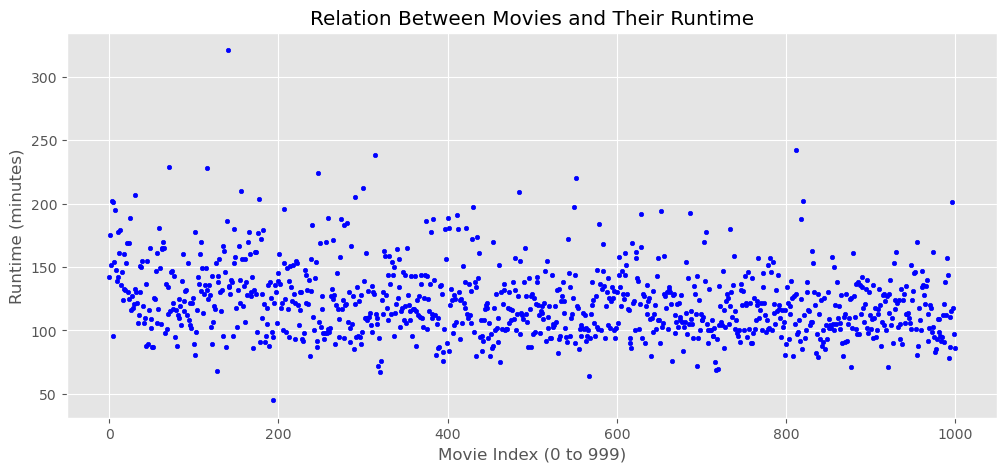

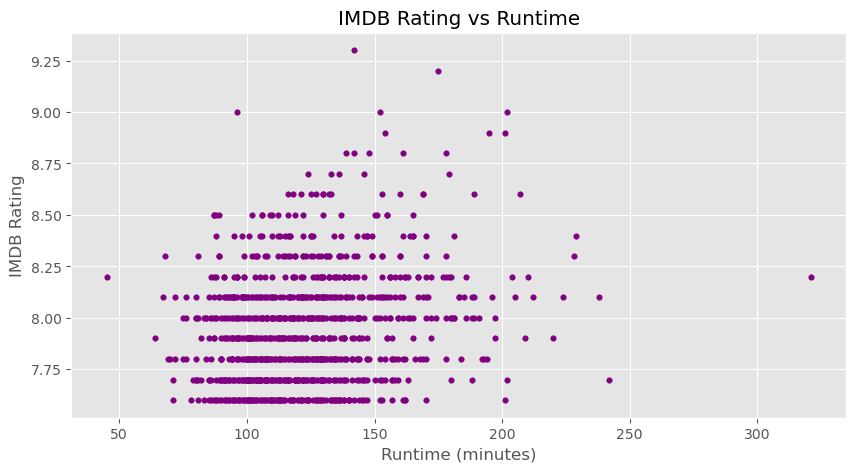

press 1 to go back to main menu OR press x to exit 1




------------------------------------------------------------------------------

Enter 1 for Analysis

Enter 2 for Movie Recommendations

Enter 3 for Graphical Comparisons

Enter 4 to See Posters



Enter your choice:  4


You selected: 4


Enter movie title (exact Title):  Inception



##################



In [ ]:
# THIS IS THE FINAL INPUT CELL.

RED = "\033[91m"
GREEN = "\033[92m"
CYAN = "\033[96m"
YELLOW = "\033[93m"
RESET = "\033[0m"

title = f"""
{GREEN}

██ ██▄  ▄██ ████▄  ▄▄▄▄      ▄████▄ ███  ██ ▄████▄ ██    ██  ██ ▄█████ ██ ▄█████   ██████ ▄████▄ ▄████▄ ██     
██ ██ ▀▀ ██ ██  ██ ██▄██ ▄▄▄ ██▄▄██ ██ ▀▄██ ██▄▄██ ██     ▀██▀  ▀▀▀▄▄▄ ██ ▀▀▀▄▄▄     ██   ██  ██ ██  ██ ██     
██ ██    ██ ████▀  ██▄█▀     ██  ██ ██   ██ ██  ██ ██████  ██   █████▀ ██ █████▀     ██   ▀████▀ ▀████▀ ██████ █
{RED}
      welcome to the I M D B   D A T A S E T   T O O L...
{RESET}
"""
    
print(title)   

def menu():
    print("\n\n------------------------------------------------------------------------------")
    print("\nEnter 1 for Analysis")
    print("\nEnter 2 for Movie Recommendations")
    print("\nEnter 3 for Graphical Comparisons")
    print("\nEnter 4 to See Posters")
    
    
    
    
    sub = input("\nEnter your choice: ").strip()
    print("You selected:", sub)
    if sub == "1":
        Analyser()
    if sub == "2":
        recom()
    elif sub == "3":
        graph_comp_menu()
    elif sub == "4":
        poster()


    x = input("press 1 to go back to main menu OR press x to exit")
    if x == "1":
        menu()
    else:
        exit()

menu()

